In [ ]:
import json
import os
import ipaddress
from collections import defaultdict
import pandas as pd
def extract_ip_addresses(file_path):
    """Extract destination IP addresses from a given JSON file."""
    ip_addresses = set()
    try:
        with open(file_path, 'r') as file:
            data = json.load(file)
        
        for measurement in data:
            dst_addr = measurement.get('dst_addr')
            if dst_addr:
                ip_addresses.add(dst_addr.strip())
    except (json.JSONDecodeError, FileNotFoundError, IOError) as e:
        print(f"Error processing {file_path}: {e}")
    
    return ip_addresses

def collect_ip_addresses_from_folder(folder_path):
    """Collect destination IPs from all JSON files in a folder."""
    ip_addresses = set()
    
    for filename in os.listdir(folder_path):
        if filename.endswith(".json"):
            file_path = os.path.join(folder_path, filename)
            ip_addresses.update(extract_ip_addresses(file_path))
    
    return ip_addresses

def count_ips_in_networks(ip_addresses):
    """Count how many IPs fall into each /24 network."""
    ip_count_in_networks = defaultdict(int)
    
    for ip_addr in ip_addresses:
        try:
            ip = ipaddress.ip_address(ip_addr)
            network = str(ipaddress.ip_network(ip.exploded + '/24', strict=False))
            ip_count_in_networks[network] += 1
        except ValueError:
            print(f"Invalid IP address encountered: {ip_addr}")
    
    print("Most common /24 networks:")
    for network, count in sorted(ip_count_in_networks.items(), key=lambda x: x[1], reverse=True)[:1]:
        print(f"{network}: {count}")
    return dict(ip_count_in_networks)

def save_results_to_csv(data, output_file):
    """Save a list of IP addresses or ASNs to a newline-separated file."""
    try:
        with open(output_file, "w") as file:
            for item in data:
                file.write(f"{item}\n")
    except IOError as e:
        print(f"Error writing to {output_file}: {e}")

    

 

    
    
input_folder = "data/raw"
output_file = "<OUTPUT_IP_LIST_TXT_PATH>"

"""Main function to process JSON files, count IPs, and save results."""
ip_addresses = collect_ip_addresses_from_folder(input_folder)
ip_addresses = set(list(ip_addresses))
ip_count_in_networks = count_ips_in_networks(ip_addresses)

print(f"Total unique IPs: {len(ip_addresses)}")
print(f"Total /24 networks: {len(ip_count_in_networks)}")
print(f"Total IP occurrences in networks: {sum(ip_count_in_networks.values())}")

csv_file = "<IPINFO_DATA_CSV_PATH>"
df = pd.read_csv(csv_file)["ip"]

print(df)

save_results_to_csv(ip_addresses, output_file)


Most common /24 networks:
142.250.74.0/24: 44
Total unique IPs: 13934
Total /24 networks: 4545
Total IP occurrences in networks: 13934
0          23.59.198.43
1         18.239.63.165
2          96.16.68.195
3          146.75.62.49
4         3.162.140.108
              ...      
12929     13.225.141.27
12930        2.22.40.22
12931     74.125.24.156
12932      23.32.24.220
12933    142.251.221.66
Name: ip, Length: 12934, dtype: object


In [21]:
count=0
for ip in ip_addresses:
    if not (df == ip).any():
        print(ip)
        count+=1
print(count)

18.154.110.80
142.250.182.134
151.101.224.157
54.192.175.55
13.35.37.28
18.64.8.120
108.157.34.231
146.75.53.140
18.172.134.113
13.224.103.91
151.101.197.44
142.250.27.84
23.62.129.14
142.251.47.98
146.75.30.217
54.230.48.156
142.250.113.157
142.251.41.70
13.35.147.94
172.217.168.2
108.138.85.14
23.63.230.8
23.47.190.200
142.251.166.154
156.251.79.10
23.1.169.10
146.75.80.84
142.250.181.102
184.26.20.187
143.204.19.75
23.32.238.211
142.251.2.156
23.205.96.227
44.194.152.208
146.75.41.140
2.19.10.173
96.16.53.150
99.84.252.67
39.125.80.39
23.73.207.13
104.108.111.241
163.181.81.31
23.198.11.19
104.96.196.22
18.67.101.112
151.101.37.42
23.214.164.20
2.16.241.18
23.36.84.209
18.165.213.40
23.62.20.118
23.45.119.197
52.84.106.27
23.201.216.234
23.205.255.204
13.33.165.34
163.181.81.33
108.157.173.109
54.230.248.99
172.217.218.84
199.232.169.44
173.194.79.149
108.157.142.127
184.25.248.194
142.250.180.130
18.64.183.30
99.86.38.105
96.17.207.162
23.45.12.40
108.157.162.95
23.206.188.139
23.6

In [ ]:
import ipinfo

access_token = "<IPINFO_API_TOKEN>"  # Provide your ipinfo API token
handler = ipinfo.getHandler(access_token)

ip = "8.8.8.8"
details = handler.getDetails(ip)

print(details.all)  # Print all details
print(f"City: {details.city}, Country: {details.country}")


{'ip': '8.8.8.8', 'hostname': 'dns.google', 'city': 'Mountain View', 'region': 'California', 'country': 'US', 'loc': '38.0088,-122.1175', 'org': 'AS15169 Google LLC', 'postal': '94043', 'timezone': 'America/Los_Angeles', 'anycast': True, 'country_name': 'United States', 'isEU': False, 'country_flag_url': 'https://cdn.ipinfo.io/static/images/countries-flags/US.svg', 'country_flag': {'emoji': '🇺🇸', 'unicode': 'U+1F1FA U+1F1F8'}, 'country_currency': {'code': 'USD', 'symbol': '$'}, 'continent': {'code': 'NA', 'name': 'North America'}, 'latitude': '38.0088', 'longitude': '-122.1175'}
City: Mountain View, Country: US


In [4]:
import pandas as pd
def analyze_csv(file_path):
    """Analyze a CSV file and provide statistics on each column."""
    df = pd.read_csv(file_path)
    
    stats = {}
    for column in df.columns:
        total_count = len(df)
        unique_count = df[column].nunique()
        empty_count = df[column].isna().sum()
        
        # Find top 3 most common values
        top_3_common = df[column].dropna().value_counts().nlargest(10).to_dict()
        
        stats[column] = {
            "Total Entries": total_count,
            "Unique Values": unique_count,
            "Empty Values": empty_count,
            "Top 3 Common Values": top_3_common
        }
    
    for col, stat in stats.items():
        print(f"Column: {col}")
        print(f"  - Total Entries: {stat['Total Entries']}")
        print(f"  - Unique Values: {stat['Unique Values']}")
        print(f"  - Empty Values: {stat['Empty Values']}")
        print(f"  - Top 3 Common Values: {stat['Top 3 Common Values']}")
        print()
    
    print(f"Empty values in 'hostname': {stats.get('hostname', {}).get('Empty Values', 'N/A')}")
    print(f"Empty values in 'loc': {stats.get('loc', {}).get('Empty Values', 'N/A')}")


In [7]:
analyze_csv("ipinfo-enrichment-results.csv")

Column: ip
  - Total Entries: 13934
  - Unique Values: 13934
  - Empty Values: 0
  - Top 3 Common Values: {'2.17.228.186': 1, '23.41.186.66': 1, '23.209.76.196': 1, '199.232.58.49': 1, '142.251.15.100': 1, '23.41.116.230': 1, '104.78.176.27': 1, '23.54.155.71': 1, '142.250.80.78': 1, '199.232.170.133': 1}

Column: status
  - Total Entries: 13934
  - Unique Values: 1
  - Empty Values: 0
  - Top 3 Common Values: {'done': 13934}

Column: type
  - Total Entries: 13934
  - Unique Values: 1
  - Empty Values: 0
  - Top 3 Common Values: {'ok': 13934}

Column: city
  - Total Entries: 13934
  - Unique Values: 217
  - Empty Values: 0
  - Top 3 Common Values: {'Ashburn': 906, 'Singapore': 812, 'Tokyo': 492, 'Atlanta': 483, 'London': 377, 'Frankfurt am Main': 369, 'Chicago': 356, 'São Paulo': 341, 'Sydney': 305, 'Miami': 279}

Column: region
  - Total Entries: 13934
  - Unique Values: 133
  - Empty Values: 0
  - Top 3 Common Values: {'Virginia': 945, 'Singapore': 818, 'California': 727, 'Georgia': 

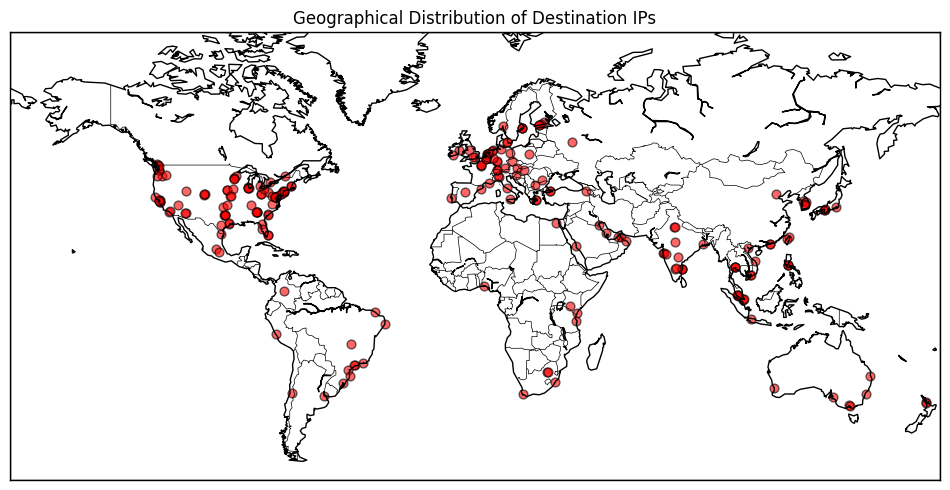

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import pandas as pd

def plot_world_map_from_csv(csv_file):
    """Plot a world map with points from the 'loc' column in a CSV file."""
    df = pd.read_csv(csv_file)
    
    if 'loc' not in df.columns:
        print("Column 'loc' not found in CSV.")
        return
    
    locations = df['loc'].dropna().unique()  # Get unique non-null locations

    latitudes, longitudes = [], []
    for loc in locations:
        try:
            lat, lon = map(float, loc.split(','))
            latitudes.append(lat)
            longitudes.append(lon)
        except ValueError:
            print(f"Skipping invalid location: {loc}")

    plt.figure(figsize=(12, 6))
    m = Basemap(projection="mill", llcrnrlat=-60, urcrnrlat=80, llcrnrlon=-180, urcrnrlon=180)

    m.drawcoastlines()
    m.drawcountries()
    m.drawmapboundary(fill_color="white")
    m.fillcontinents(color="white", lake_color="white")

    # Plot points
    x, y = m(longitudes, latitudes)
    m.scatter(x, y, marker="o", color="red", alpha=0.6, edgecolors="black", s=40)

    # Save the plot
    plt.title("Geographical Distribution of Destination IPs")
    plt.savefig("<DESTINATION_IPS_WORLD_MAP_PDF_PATH>", format="pdf", bbox_inches="tight")
    plt.show()

plot_world_map_from_csv("ipinfo-enrichment-results.csv")

In [1]:
import json
import os
import ipaddress
from collections import defaultdict
import pandas as pd
def extract_ip_addresses(file_path):
    """Extract destination IP addresses from a given JSON file."""
    ip_addresses = set()
    try:
        with open(file_path, 'r') as file:
            data = json.load(file)
        
        for measurement in data:
            dst_addr = measurement.get('src_addr')
            if dst_addr:
                ip_addresses.add(dst_addr.strip())
    except (json.JSONDecodeError, FileNotFoundError, IOError) as e:
        print(f"Error processing {file_path}: {e}")
    
    return ip_addresses

def collect_ip_addresses_from_folder(folder_path):
    """Collect destination IPs from all JSON files in a folder."""
    ip_addresses = set()
    
    for filename in os.listdir(folder_path):
        if filename.endswith(".json"):
            file_path = os.path.join(folder_path, filename)
            ip_addresses.update(extract_ip_addresses(file_path))
    
    return ip_addresses

In [3]:
a = collect_ip_addresses_from_folder("measurement_results_combined")

In [6]:
def count_ips_in_networks(ip_addresses):
    """Count how many IPs fall into each /24 network."""
    ip_count_in_networks = defaultdict(int)
    
    for ip_addr in ip_addresses:
        try:
            ip = ipaddress.ip_address(ip_addr)
            network = str(ipaddress.ip_network(ip.exploded + '/24', strict=False))
            ip_count_in_networks[network] += 1
        except ValueError:
            print(f"Invalid IP address encountered: {ip_addr}")
    
    print("Most common /24 networks:")
    for network, count in sorted(ip_count_in_networks.items(), key=lambda x: x[1], reverse=True)[:1]:
        print(f"{network}: {count}")
    return dict(ip_count_in_networks)

In [5]:
print(len(a))

69


In [7]:
b = count_ips_in_networks(a)

Most common /24 networks:
156.154.123.0/24: 1


In [8]:
len(b)

69

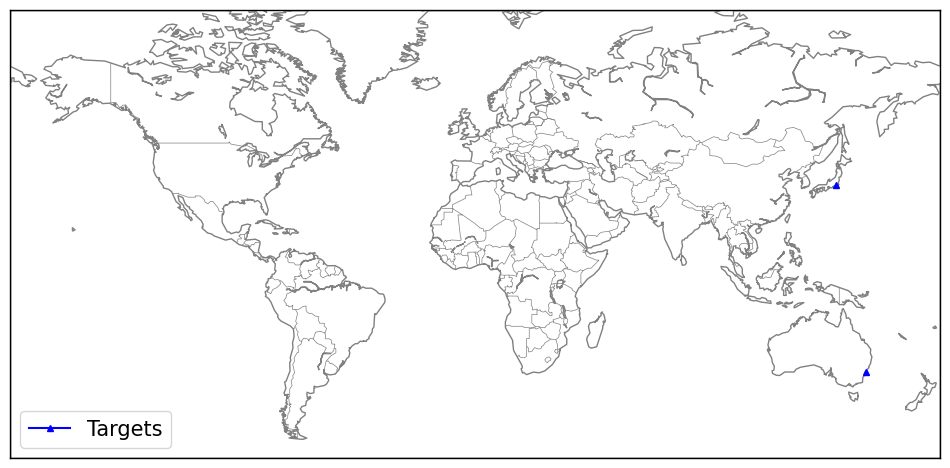

In [26]:
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap

def world_map_plot(set1, set2):
    plt.figure(figsize=(12, 6))
    m = Basemap(projection="mill", llcrnrlat=-60, urcrnrlat=80, llcrnrlon=-180, urcrnrlon=180)


# Draw coastlines, countries, and states with reduced intensity
    m.drawcoastlines(linewidth=1, color="gray")
    m.drawcountries(linewidth=0.5, color="gray")
# m.drawstates(linewidth=0.2, color="gray", alpha=0.4)
    # m.drawcoastlines()
    # m.drawcountries()
    m.drawmapboundary(fill_color="white")
    m.fillcontinents(color="white", lake_color="white")

    # # Plot first set (red)
    # for lon, lat in set1:
    #     x, y = m(lon, lat)
    #     m.plot(x, y, marker="v", color="red", markersize=7, label="Vantage Points" if set1.index((lon, lat)) == 0 else "")

    # Plot second set (blue)
    for lon, lat in set2:
        x, y = m(lon, lat)
        m.plot(x, y, marker="^", color="blue", markersize=5, label="Targets" if set2.index((lon, lat)) == 0 else "")

    # Add legend
    plt.legend(loc="lower left", fontsize=15)
    # plt.title("World Map with Two Sets of Coordinates")
    
    plt.savefig("world_map.pdf", format="pdf", bbox_inches="tight")
    plt.show()

if __name__ == "__main__":
    # Example coordinates
    set1 = [(-74.0060, 40.7128), (-0.1278, 51.5074)]  # New York, London
    set2 = [(139.6917, 35.6895), (151.2093, -33.8688)]  # Tokyo, Sydney

    world_map_plot(set1, set2)


In [ ]:
import csv

def get_unique_locations(csv_file):
    unique_locations = set()

    with open(csv_file, newline='', encoding='utf-8') as file:
        reader = csv.DictReader(file)
        
        for row in reader:
            if 'loc' in row:
                loc_value = row['loc'].strip()
                unique_locations.add(loc_value)
    
    return list(unique_locations)

# Example usage
csv_file_path = '<IPINFO_ENRICHMENT_RESULTS_CSV_PATH>'  # Path to CSV file
unique_locations = get_unique_locations(csv_file_path)

print(unique_locations)  # Print the list of unique locations


['34.8164,135.5683', '48.8534,2.3488', '39.9075,116.3972', '-25.4278,-49.2731', '39.3111,-94.6650', '44.9800,-93.2638', '22.3279,114.2499', '49.2497,-123.1193', '59.3000,18.0500', '41.4995,-81.6954', '48.9356,2.3539', '34.6913,135.1830', '38.9687,-77.3411', '38.1166,13.3636', '51.5085,-0.1257', '13.9130,100.4988', '50.8505,4.3488', '33.4148,-111.9093', '39.0751,-78.5978', '29.9324,-95.3802', '-33.9258,18.4232', '53.3331,-6.2489', '33.9192,-118.4165', '-23.5475,-46.6361', '34.0522,-118.2437', '55.6759,12.5655', '52.3740,4.8897', '32.9482,-96.7297', '43.2970,5.3811', '-4.0547,39.6636', '39.0437,-77.4875', '23.5841,58.4078', '19.1167,72.9833', '32.8546,-79.9748', '43.7064,-79.3986', '37.4419,-122.1430', '2.6931,101.7498', '45.5946,-121.1787', '36.1962,-86.6225', '-6.2146,106.8451', '19.0728,72.8826', '37.3394,-121.8950', '47.6062,-122.3321', '50.0880,14.4208', '35.4676,-97.5164', '-33.8678,151.2073', '41.0048,29.0448', '42.3584,-71.0598', '38.7167,-9.1333', '60.8667,26.7000', '26.2034,-98

In [13]:
set3 =[ tuple(reversed(list(map(float, x.split(','))))) for x in unique_locations if ',' in x]

In [14]:
set3

[(135.5683, 34.8164),
 (2.3488, 48.8534),
 (116.3972, 39.9075),
 (-49.2731, -25.4278),
 (-94.665, 39.3111),
 (-93.2638, 44.98),
 (114.2499, 22.3279),
 (-123.1193, 49.2497),
 (18.05, 59.3),
 (-81.6954, 41.4995),
 (2.3539, 48.9356),
 (135.183, 34.6913),
 (-77.3411, 38.9687),
 (13.3636, 38.1166),
 (-0.1257, 51.5085),
 (100.4988, 13.913),
 (4.3488, 50.8505),
 (-111.9093, 33.4148),
 (-78.5978, 39.0751),
 (-95.3802, 29.9324),
 (18.4232, -33.9258),
 (-6.2489, 53.3331),
 (-118.4165, 33.9192),
 (-46.6361, -23.5475),
 (-118.2437, 34.0522),
 (12.5655, 55.6759),
 (4.8897, 52.374),
 (-96.7297, 32.9482),
 (5.3811, 43.297),
 (39.6636, -4.0547),
 (-77.4875, 39.0437),
 (58.4078, 23.5841),
 (72.9833, 19.1167),
 (-79.9748, 32.8546),
 (-79.3986, 43.7064),
 (-122.143, 37.4419),
 (101.7498, 2.6931),
 (-121.1787, 45.5946),
 (-86.6225, 36.1962),
 (106.8451, -6.2146),
 (72.8826, 19.0728),
 (-121.895, 37.3394),
 (-122.3321, 47.6062),
 (14.4208, 50.088),
 (-97.5164, 35.4676),
 (151.2073, -33.8678),
 (29.0448, 41

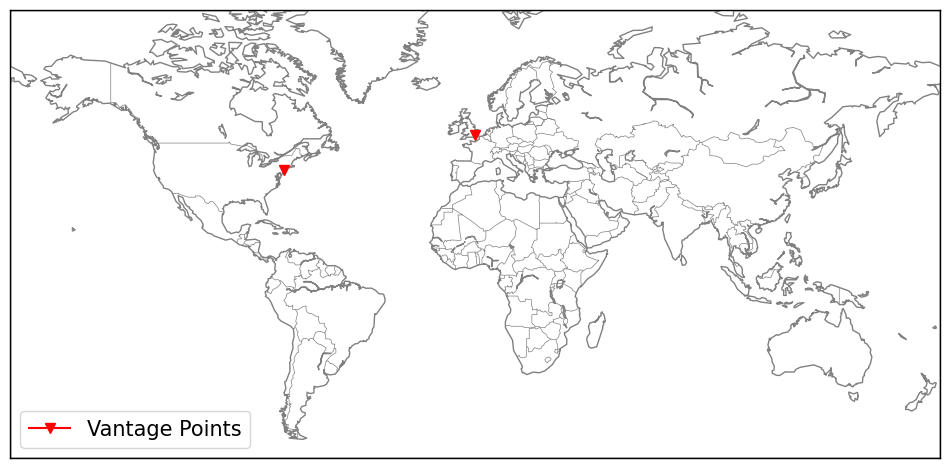

In [16]:
world_map_plot(set1, set3)

In [17]:
set4 = [
        ("3387", [55.1864589, 25.0236107]),
        ("3045", [151.1884302, -33.9208487]),
        ("2218", [8.6954089, 50.1137156]),
        ("1987", [114.123715, 22.3520405]),
        ("3043", [139.7451371, 35.6674565]),
        ("3315", [127.0373932, 37.4999072]),
        ("2761", [101.686855, 3.139003]),
        ("2219", [32.5771309, -25.9751272]),
        ("2756", [103.819836, 1.352083]),
        ("2328", [121.577712, 25.073509]),
        ("2758", [-0.0138439, 51.4992089]),
        ("2298", [-118.2557059, 34.0479152]),
        ("1988", [-77.364564, 38.9506292]),
        ("2220", [28.2021014, -26.1365724]),
        ("1975", [151.1893, -33.9181984]),
        ("1974", [-46.8362828, -23.485198]),
        ("1984", [2.3635156, 48.877009]),
        ("1978", [9.1474362, 45.4486839]),
        ("1926", [139.790771, 35.6522452]),
        ("1947", [126.8797332, 37.4820962]),
        ("1982", [21.00425, 52.2276614]),
        ("1976", [28.8273319, 40.993267]),
        ("1990", [-0.01484, 51.499732]),
        ("1925", [-87.618252, 41.853701]),
        ("1945", [-80.1931295, 25.7758686]),
        ("1526", [151.1929422, -33.9117762]),
        ("1521", [-79.3617799, 43.6508826]),
        ("1525", [8.73561, 50.12007]),
        ("1522", [2.3711084, 48.9065203]),
        ("1528", [139.7448846, 35.6208612]),
        ("1524", [4.6647595, 52.3908925]),
        ("2896", [17.8752145, 59.3909289]),
        ("1527", [103.695253, 1.3218215]),
        ("1523", [-0.0737773, 51.5203975]),
        ("1518", [-84.4208774, 33.7777175]),
        ("1512", [-87.9619655, 41.9942563]),
        ("2471", [56.33641, 25.1308322]),
        ("2472", [144.9153835, -37.8230112]),
        ("2473", [151.1893, -33.9181984]),
        ("2474", [-46.8093581, -23.4935247]),
        ("2475", [-74.1619252, 4.67135]),
        ("2484", [-3.5740775, 40.4479561]),
        ("2519", [72.871348, 19.0696137]),
        ("2523", [77.2401945, 28.5428603]),
        ("2495", [21.0024361, 52.1533997]),
        ("2498", [121.5761848, 25.0756131]),
        ("2507", [28.1975446, -26.138037]),
        ("1061", [-46.6333094, -23.5505199]),
        ("1279", [114.109497, 22.396428]),
        ("1278", [139.6917064, 35.6894875]),
        ("1280", [103.819836, 1.352083]),
        ("1064", [-77.4874416, 39.0437567]),
        ("1793", [-84.3879824, 33.7489954]),
        ("998", [153.0957651, -27.5777854]),
        ("331", [153.0235024, -27.4709331]),
        ("1491", [151.1929422, -33.9117762]),
        ("1110", [-43.96451692, -19.86879148]),
        ("2334", [-43.9677359, -19.870682]),
        ("1164", [-51.1206198, -30.0688963]),
        ("3116", [-121.9201106, 37.4718094]),
        ("2544", [-95.4590244, 30.0659871]),
        ("2898", [139.747765, 35.622214]),
        ("1475", [139.7194156, 35.7312536]),
        ("3256", [103.819836, 1.352083]),
        ("2873", [103.819836, 1.352083]),
        ("803", [-2.438261, 53.578741]),
        ("2067", [-2.4392645, 53.5790087]),
        ("848", [-1.31207335, 51.57766072]),
        ("1915", [-0.624524, 51.52036494]),
        ("1370", [9.6053289, 47.2703929]),
        ("1744", [-70.6455164, -33.4390748]),
        ("1211", [24.8950162, 60.20640511]),
        ("326", [19.040235, 47.497912]),
        ("799", [47.9439836, 29.3438394]),
        ("1346", [-100.1806902, 25.7845395]),
        ("1224", [39.10741478, 22.3087422]),
        ("2181", [-63.0471371, 18.0295839]),
        ("789", [39.28877771, -6.81328337]),
        ("2026", [106.7028941, 10.7882534]),
    ]

In [18]:
set4 = [tuple(y) for x,y in set4]

In [19]:
set4


[(55.1864589, 25.0236107),
 (151.1884302, -33.9208487),
 (8.6954089, 50.1137156),
 (114.123715, 22.3520405),
 (139.7451371, 35.6674565),
 (127.0373932, 37.4999072),
 (101.686855, 3.139003),
 (32.5771309, -25.9751272),
 (103.819836, 1.352083),
 (121.577712, 25.073509),
 (-0.0138439, 51.4992089),
 (-118.2557059, 34.0479152),
 (-77.364564, 38.9506292),
 (28.2021014, -26.1365724),
 (151.1893, -33.9181984),
 (-46.8362828, -23.485198),
 (2.3635156, 48.877009),
 (9.1474362, 45.4486839),
 (139.790771, 35.6522452),
 (126.8797332, 37.4820962),
 (21.00425, 52.2276614),
 (28.8273319, 40.993267),
 (-0.01484, 51.499732),
 (-87.618252, 41.853701),
 (-80.1931295, 25.7758686),
 (151.1929422, -33.9117762),
 (-79.3617799, 43.6508826),
 (8.73561, 50.12007),
 (2.3711084, 48.9065203),
 (139.7448846, 35.6208612),
 (4.6647595, 52.3908925),
 (17.8752145, 59.3909289),
 (103.695253, 1.3218215),
 (-0.0737773, 51.5203975),
 (-84.4208774, 33.7777175),
 (-87.9619655, 41.9942563),
 (56.33641, 25.1308322),
 (144.91538

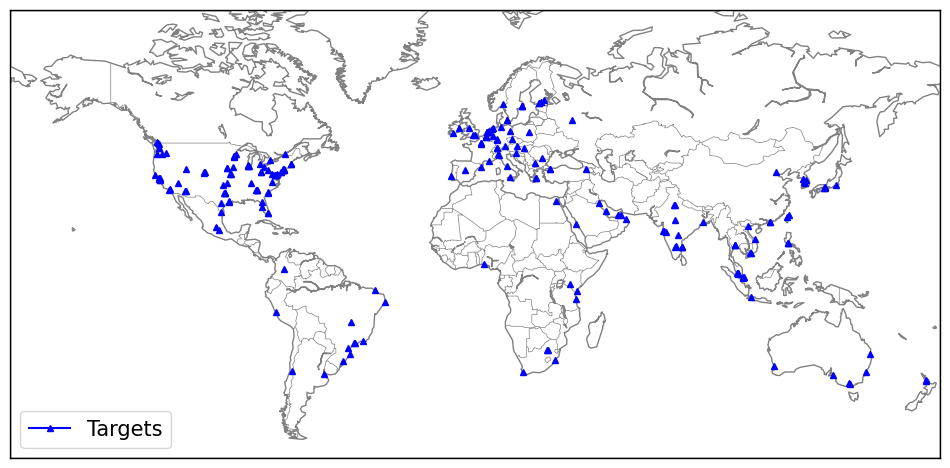

In [27]:
world_map_plot(set4, set3)

In [ ]:
import requests
import json

def get_anchor_details(anchor_numbers, base_url="https://atlas.ripe.net/api/v2/anchors/"):
    """
    Fetch ASN, geolocated coordinates, and country for each RIPE Atlas anchor.
    """
    anchor_details = []

    for anchor in anchor_numbers:
        try:
            # Construct the API URL
            url = f"{base_url}{anchor}/"
            response = requests.get(url)

            if response.status_code == 200:
                data = response.json()
                
                # Extract details
                coordinates = data["geometry"]["coordinates"]  # [longitude, latitude]
                country = data["country"]
                asn = data["as_v4"] if "as_v4" in data else None  # ASN for IPv4
                ip_v4 = data["ip_v4"]
                # Append results as a dictionary
                anchor_details.append({
                    "ip_v4": ip_v4,
                    "anchor": anchor,
                    "asn": asn,
                    "coordinates": (coordinates[1], coordinates[0]),  # Convert to (lat, lon)
                    "country": country
                })
            else:
                print(f"Failed to fetch data for anchor {anchor}. Status code: {response.status_code}")

        except Exception as e:
            print(f"An error occurred for anchor {anchor}: {e}")

    return anchor_details


# Example Usage:
# anchor_numbers = [3387, 3045, 2218, 1987, 3043]  # Replace with actual anchor IDs
# anchor_data = get_anchor_details(anchor_numbers)

# # Print the results
# for entry in anchor_data:
#     print(entry)

with open('data/anchor_probe_info/anchor_probe_info.json', 'r') as file:
    data = json.load(file)

In [22]:
anchor_data = get_anchor_details(data)

In [23]:
print(anchor_data)

[{'ip_v4': '63.222.248.5', 'anchor': '3387', 'asn': 3491, 'coordinates': (25.0236107, 55.1864589), 'country': 'AE'}, {'ip_v4': '63.222.191.5', 'anchor': '3045', 'asn': 3491, 'coordinates': (-33.9208487, 151.1884302), 'country': 'AU'}, {'ip_v4': '207.226.224.236', 'anchor': '2218', 'asn': 3491, 'coordinates': (50.1137156, 8.6954089), 'country': 'DE'}, {'ip_v4': '63.222.7.46', 'anchor': '1987', 'asn': 3491, 'coordinates': (22.3520405, 114.123715), 'country': 'HK'}, {'ip_v4': '63.222.190.5', 'anchor': '3043', 'asn': 3491, 'coordinates': (35.6674565, 139.7451371), 'country': 'JP'}, {'ip_v4': '63.222.106.8', 'anchor': '3315', 'asn': 3491, 'coordinates': (37.4999072, 127.0373932), 'country': 'KR'}, {'ip_v4': '63.222.188.9', 'anchor': '2761', 'asn': 3491, 'coordinates': (3.139003, 101.686855), 'country': 'MY'}, {'ip_v4': '41.221.208.94', 'anchor': '2219', 'asn': 3491, 'coordinates': (-25.9751272, 32.5771309), 'country': 'MZ'}, {'ip_v4': '63.222.189.7', 'anchor': '2756', 'asn': 3491, 'coordina

In [24]:
from collections import defaultdict

In [25]:
combiner = defaultdict(list)
for entry in anchor_data:
    combiner['coordinates'].append(entry['coordinates'])
    combiner['asn'].append(entry['asn'])
    combiner['country'].append(entry['country'])
    combiner['anchor'].append(entry['anchor'])

# for entry in anchor_data:
#     print(entry)
#     print(entry['coordinates'])
#     print(entry['asn'])
#     print(entry['country'])
#     print(entry['anchor'])

In [ ]:
print(combiner)

defaultdict(<class 'list'>, {'coordinates': [(25.0236107, 55.1864589), (-33.9208487, 151.1884302), (50.1137156, 8.6954089), (22.3520405, 114.123715), (35.6674565, 139.7451371), (37.4999072, 127.0373932), (3.139003, 101.686855), (-25.9751272, 32.5771309), (1.352083, 103.819836), (25.073509, 121.577712), (51.4992089, -0.0138439), (34.0479152, -118.2557059), (38.9506292, -77.364564), (-26.1365724, 28.2021014), (-33.9181984, 151.1893), (-23.485198, -46.8362828), (48.877009, 2.3635156), (45.4486839, 9.1474362), (35.6522452, 139.790771), (37.4820962, 126.8797332), (52.2276614, 21.00425), (40.993267, 28.8273319), (51.499732, -0.01484), (41.853701, -87.618252), (25.7758686, -80.1931295), (-33.9117762, 151.1929422), (43.6508826, -79.3617799), (50.12007, 8.73561), (48.9065203, 2.3711084), (35.6208612, 139.7448846), (52.3908925, 4.6647595), (59.3909289, 17.8752145), (1.3218215, 103.695253), (51.5203975, -0.0737773), (33.7777175, -84.4208774), (41.9942563, -87.9619655), (25.1308322, 56.33641), (-3

In [103]:
for key, value in combiner.items():
    a = set(value)
    print(key, len(a))

coordinates 74
asn 27
country 34
anchor 79


In [ ]:
import csv
import geoip2.database

# Path to your MaxMind GeoLite2 database files
asn_db_file = '<GEOLITE2_ASN_MMDB_PATH>'
city_db_file = '<GEOLITE2_CITY_MMDB_PATH>'

# Initialize the readers
asn_reader = geoip2.database.Reader(asn_db_file)
city_reader = geoip2.database.Reader(city_db_file)

def get_country(ip):
    """
    Look up the country code for the given IP address using the GeoLite2-City database.
    """
    try:
        response = city_reader.city(ip)
        return response.country.iso_code  # Return country code (e.g., 'US', 'TR')
    except Exception:
        return None

def get_asn(ip):
    """
    Look up the Autonomous System Number (ASN) for the given IP address
    using the GeoLite2-ASN database.
    """
    try:
        response = asn_reader.asn(ip)
        return str(response.autonomous_system_number)
    except Exception:
        return None

def compare_anchor_with_maxmind(anchor_details):
    total = 0
    correct_country = 0
    incorrect_country = 0
    correct_asn = 0
    incorrect_asn = 0

    for anchor in anchor_details:
        ip = anchor.get("ip_v4")
        anchor_country = anchor.get("country")
        anchor_asn = anchor.get("asn")

        if not ip:
            continue  # Skip entries without an IP

        maxmind_country = get_country(ip)
        maxmind_asn = get_asn(ip)

        total += 1

        # Check country match
        if anchor_country == maxmind_country:
            correct_country += 1
        else:
            incorrect_country += 1
            print(f"[Country Mismatch] IP: {ip}, Anchor: {anchor_country}, MaxMind: {maxmind_country}")

        # Check ASN match
        if str(anchor_asn) == maxmind_asn:
            correct_asn += 1
        else:
            incorrect_asn += 1
            print(f"[ASN Mismatch] IP: {ip}, Anchor ASN: {anchor_asn}, MaxMind ASN: {maxmind_asn}")

    accuracy_country = (correct_country / total) * 100 if total > 0 else 0
    accuracy_asn = (correct_asn / total) * 100 if total > 0 else 0

    print("\n### Comparison Results ###")
    print(f"Total IPs Checked: {total}")
    print(f"Correct Country Matches: {correct_country}")
    print(f"Incorrect Country Matches: {incorrect_country}")
    print(f"Country Accuracy: {accuracy_country:.2f}%")
    print(f"Correct ASN Matches: {correct_asn}")
    print(f"Incorrect ASN Matches: {incorrect_asn}")
    print(f"ASN Accuracy: {accuracy_asn:.2f}%")

# # Example anchor details list
# anchor_details = [
#     {"ip_v4": "8.8.8.8", "anchor": 3387, "asn": 15169, "coordinates": (37.386, -122.083), "country": "US"},
#     {"ip_v4": "1.1.1.1", "anchor": 3045, "asn": 13335, "coordinates": (-27.4705, 153.026), "country": "AU"},
#     {"ip_v4": "208.67.222.222", "anchor": 2218, "asn": 36692, "coordinates": (38.0, -97.0), "country": "US"},
# ]

# Run comparison
compare_anchor_with_maxmind(anchor_data)

# Close the database readers
city_reader.close()
asn_reader.close()


[Country Mismatch] IP: 207.226.224.236, Anchor: DE, MaxMind: US
[Country Mismatch] IP: 63.222.106.8, Anchor: KR, MaxMind: US
[Country Mismatch] IP: 41.221.208.94, Anchor: MZ, MaxMind: ZA
[Country Mismatch] IP: 63.222.40.114, Anchor: TW, MaxMind: US
[Country Mismatch] IP: 41.79.249.228, Anchor: ZA, MaxMind: TZ
[ASN Mismatch] IP: 146.185.214.58, Anchor ASN: 199524, MaxMind ASN: 202422
[ASN Mismatch] IP: 5.188.238.222, Anchor ASN: 199524, MaxMind ASN: 202422
[ASN Mismatch] IP: 5.188.93.37, Anchor ASN: 199524, MaxMind ASN: 202422
[ASN Mismatch] IP: 92.223.93.208, Anchor ASN: 199524, MaxMind ASN: 202422
[ASN Mismatch] IP: 92.38.178.149, Anchor ASN: 199524, MaxMind ASN: 202422
[ASN Mismatch] IP: 92.38.135.131, Anchor ASN: 199524, MaxMind ASN: 202422
[ASN Mismatch] IP: 5.188.108.64, Anchor ASN: 199524, MaxMind ASN: 202422
[ASN Mismatch] IP: 5.188.168.94, Anchor ASN: 199524, MaxMind ASN: 202422
[ASN Mismatch] IP: 92.223.59.77, Anchor ASN: 199524, MaxMind ASN: 202422
[ASN Mismatch] IP: 92.38.17